# 24 — evtol.news photo set: collection, filter, sets, extraction, attention

Thin notebook: it only **imports** and **calls** `src/evtolnews.py`, `src/evtolnews_sets.py` and `src/attention_maps.py`, then **displays** the results.

**Question:** do real photographs of eVTOL aircraft give the embedding pipeline an independent test of the patent results? The Vertical Flight Society's World eVTOL Aircraft Directory (evtol.news) lists every known design in five classes (Vectored Thrust, Lift + Cruise, Wingless (Multicopter), Electric Rotorcraft, Hover Bikes / PFD), with photos and renders. The classes are the parent groups of the codebook's 12 topTypes.

**Steps:** 1 collect (index, pages, images) · 2 whole-aircraft filter (SigLIP + rules) · 3 figure sets (main, all, built, concept) · 4 processing (notebook 21's code) · 5 extraction (notebook 22's code, plus a copy of the patent figures embedded with the same model) · 6 CLS-token attention maps.

**Output:** `evtolnews.root` (`EVTOLNEWS_DS/`): `0_source/`, `1_filter/`, `2_embedding_extraction/` (same layout as `paths.pipeline_root`: `selection/`, `processed/`, `embeddings/`, `patent_reference/`, `attention/`). The patent tree is only read.

**Private:** the images are (c) their owners, used for embeddings only. Nothing is published before the source is asked.

Kernel: base Python (`python3`), which has `open_clip` for the SigLIP filter. Every step skips work already on disk.

In [1]:
import sys, json
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / 'config.yaml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import Image, Markdown, display
from src.config_loader import load_config
from src import evtolnews as E, evtolnews_sets as S

cfg = load_config()
en = cfg['evtolnews']
root = E.root(cfg)
print(root)

/mnt/storage_11tb/Drive_files_to_syncronize/3 - Images DataSets & Labelling Outputs/EVTOLNEWS_DS


## 1. Collect

The directory index, the aircraft pages and their images. Fetching again is off by default: the crawl of 2026-09-17 is on disk (1 229 pages, 3 679 images, no error). Set `REFRESH_CRAWL = True` to pick up new directory entries; saved pages and images are not fetched twice.

In [2]:
REFRESH_CRAWL = False
if REFRESH_CRAWL:
    E.build_index(cfg)
    E.crawl_pages(cfg, en['crawl_workers'], en['crawl_pause_s'])
    E.parse_pages(cfg)
    E.download_images(cfg, en['crawl_workers'], en['crawl_pause_s'])

ac = pd.read_csv(E.source_dir(cfg) / 'aircraft.csv', keep_default_na=False)
im = pd.read_csv(E.source_dir(cfg) / 'images.csv', keep_default_na=False)
print(f"{len(ac)} aircraft pages, {len(im)} images")
display(ac['evtol_class_main'].value_counts().rename('aircraft').to_frame())
display(pd.Series({c: f"{(ac[c] != '').mean():.0%}" for c in ['model', 'company', 'location', 'status', 'spec_aircraft_type']},
                  name='filled').to_frame())

1229 aircraft pages, 3679 images


,aircraft
evtol_class_main,
VT,426
WM,365
LC,225
HB,127
ER,86


,filled
model,99%
company,99%
location,98%
status,63%
spec_aircraft_type,90%


## 2. Whole-aircraft filter

Hard rules first (failed download, side under 200 px, a file already used by another page, a file from another aircraft's media folder), then SigLIP zero-shot against prompt groups: keep at p(whole aircraft) 0.80 or more, drop under 0.35, hold the band between for review. `1_filter/manual_decisions.csv` overrides everything. The SigLIP features are cached, so only a prompt change re-runs the model.

[filter] {"images": 3679, "auto": {"keep": 3063, "drop": 377, "review": 239}, "hard_rule": {"": 3543, "other_aircraft_page": 65, "same_file_on_other_page": 65, "too_small": 6}, "kept": 3063, "manual": 0, "aircraft_with_kept_image": 1157, "thresholds": {"keep_p": 0.8, "drop_p": 0.35, "page_sim_flag": 0.55}}


{'images': 3679,
 'auto': {'keep': 3063, 'drop': 377, 'review': 239},
 'hard_rule': {'': 3543,
  'other_aircraft_page': 65,
  'same_file_on_other_page': 65,
  'too_small': 6},
 'kept': 3063,
 'manual': 0,
 'aircraft_with_kept_image': 1157,
 'thresholds': {'keep_p': 0.8, 'drop_p': 0.35, 'page_sim_flag': 0.55}}

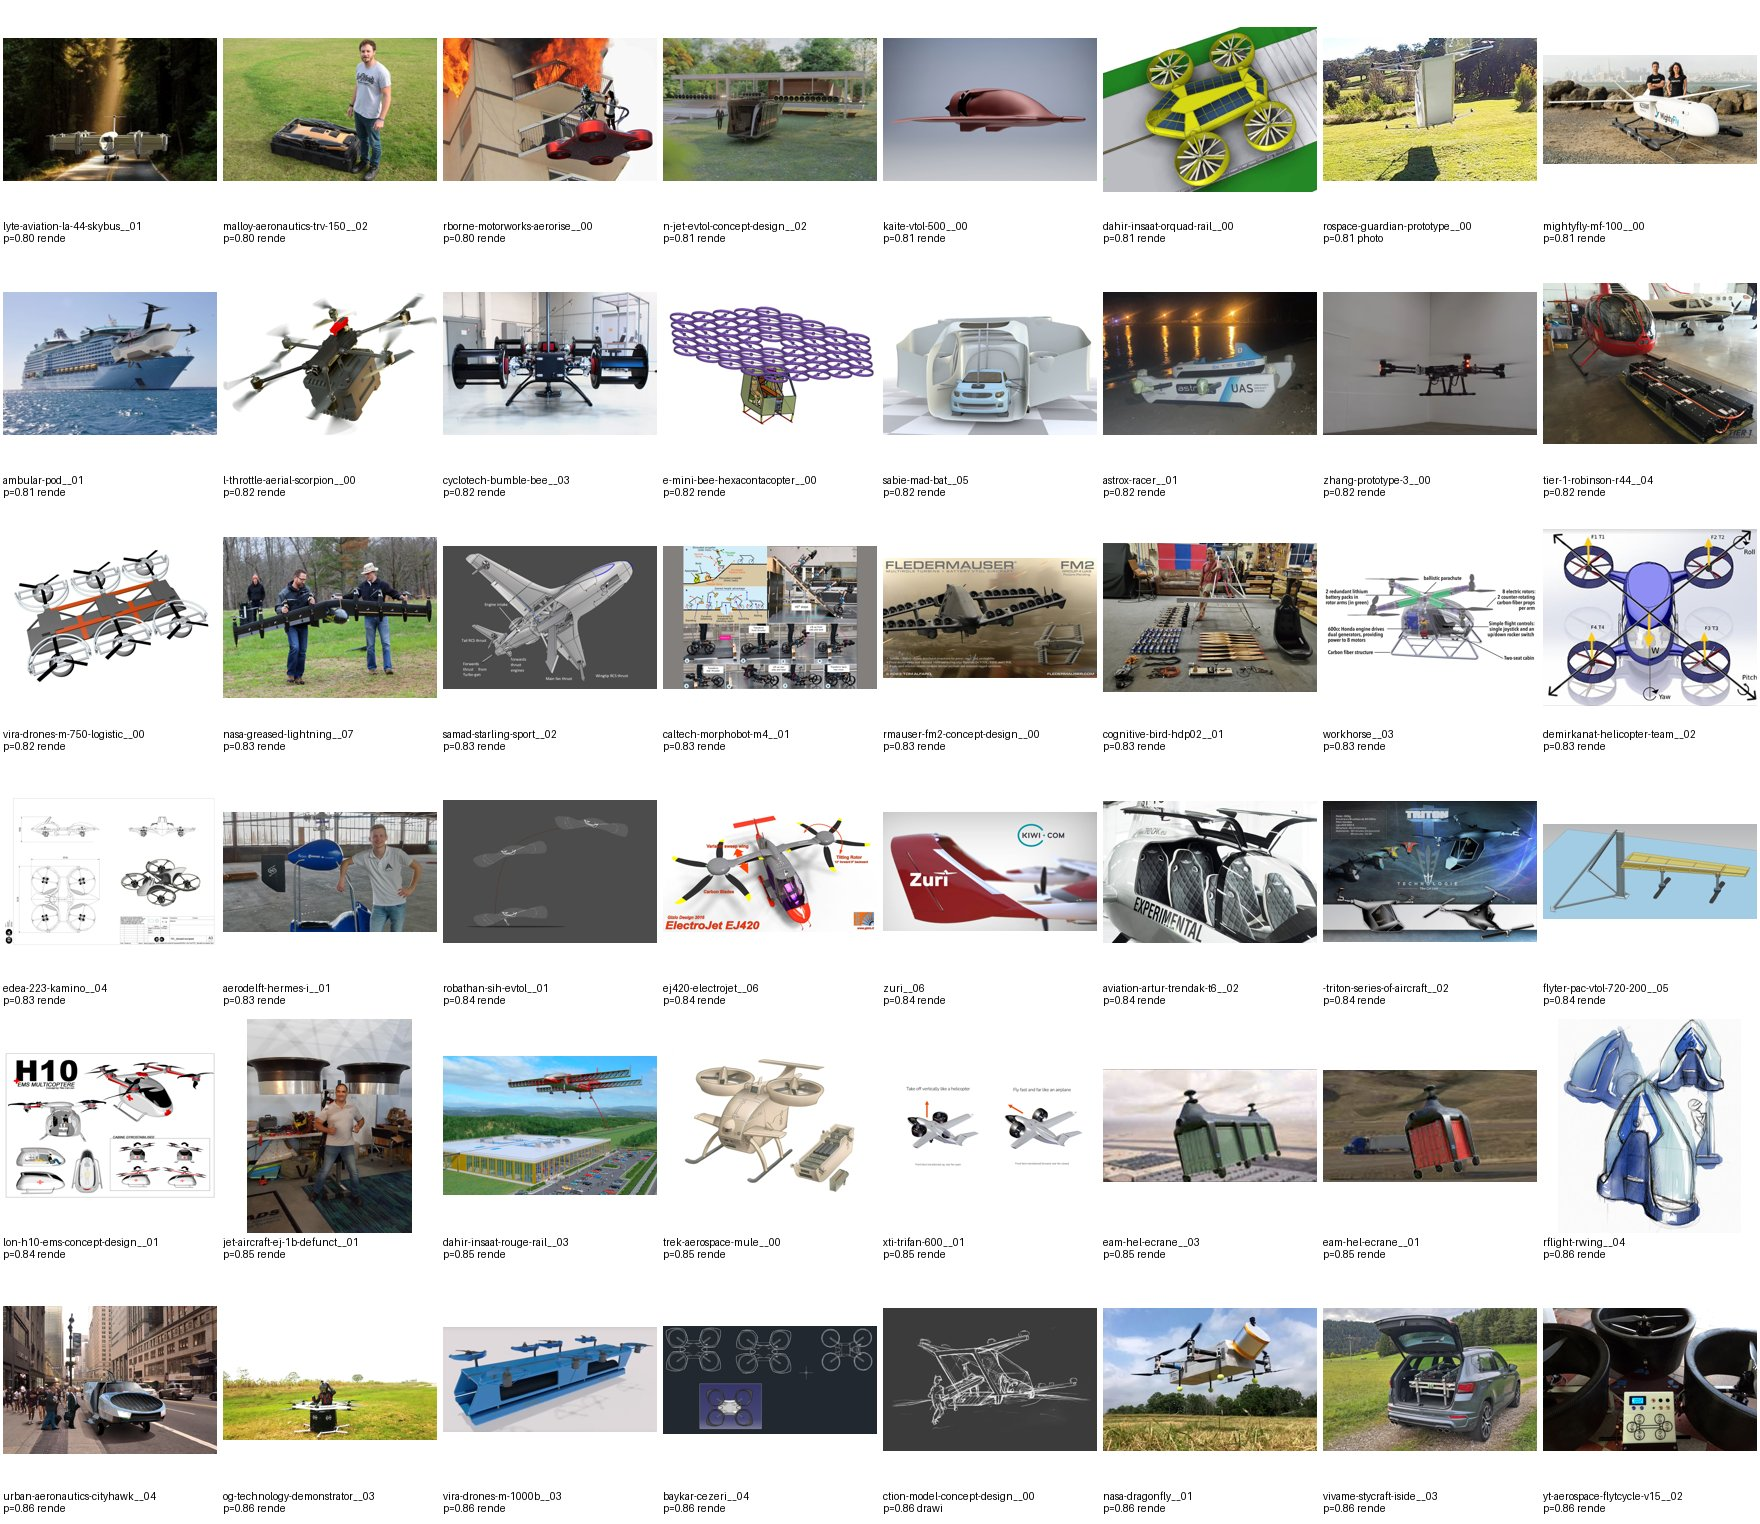

In [3]:
decisions = S.run_filter(cfg)
display(json.loads((S.filter_dir(cfg) / 'filter_summary.json').read_text()))
display(Image(filename=str(S.filter_dir(cfg) / 'sheets' / 'keep_lowest_0.jpg'), width=900))

## 3. Figure sets

`main` = the page's first kept image (one per aircraft), `all` = every kept image, `built` / `concept` = the main image by the directory's own status. Same files as notebook 20 writes for the patents.

In [4]:
sets = S.run_sets(cfg)
pd.DataFrame({k: {'figures': len(v), 'aircraft': v['aircraft_uid'].nunique()} for k, v in sets.items()}).T

[selection] wrote 4 sets (3063 unique figures) to /mnt/storage_11tb/Drive_files_to_syncronize/3 - Images DataSets & Labelling Outputs/EVTOLNEWS_DS/2_embedding_extraction/selection
topType  aircraft  main  all  built  concept
     VT       410   410  410     59      176
     WM       332   332  332     87       98
     LC       218   218  218     78       70
     HB       114   114  114     21       20
     ER        83    83   83     11       31


,figures,aircraft
main,1157,1157
all,3063,1157
built,256,256
concept,395,395


## 4. Processing (notebook 21's code)

Resize with the aspect ratio kept and pad to a white square, at 224 and 518 px. No rotation: photos carry none.

In [5]:
S.run_process(cfg)

224px:   0%|          | 0/3063 [00:00<?, ?it/s]

224px:   1%|          | 17/3063 [00:00<00:18, 165.98it/s]

224px:   1%|▏         | 39/3063 [00:00<00:15, 193.74it/s]

224px:   2%|▏         | 62/3063 [00:00<00:14, 209.30it/s]

224px:   3%|▎         | 83/3063 [00:00<00:14, 205.35it/s]

...

518px:  65%|██████▌   | 1991/3063 [00:00<00:00, 5253.03it/s]

518px:  82%|████████▏ | 2517/3063 [00:00<00:00, 3872.39it/s]

518px:  96%|█████████▋| 2949/3063 [00:00<00:00, 3498.44it/s]

518px: 100%|██████████| 3063/3063 [00:00<00:00, 3847.60it/s]

[processing] 3063 figures at 518px -> /mnt/storage_11tb/Drive_files_to_syncronize/3 - Images DataSets & Labelling Outputs/EVTOLNEWS_DS/2_embedding_extraction/processed/518


## 5. Extraction (notebook 22's code)

DINOv2-large, frozen, layers 18 / 22 / 24 × CLS token / mean of the patch tokens, for both sizes. The patents' processed figures are embedded again with the same model into `patent_reference/<tag>/`, for the patent ↔ photo matching; the patent tree is not written. Runs are skipped when the figure set has not changed.

In [6]:
S.run_extract(cfg)

[extraction] dinov2-large_224: up to date (3063 figures) — skipped
[extract] patent_reference/dinov2-large_224: up to date
[extraction] dinov2-large_518: up to date (3063 figures) — skipped
[extract] patent_reference/dinov2-large_518: up to date


## 6. CLS-token attention maps

For the main image of every directory aircraft and of every patent aircraft, at 518 px: the CLS query of blocks 18, 22 and 24 against every patch key, rebuilt from the block's own weights (softmax over all tokens, mean over the 16 heads). From block 22 on, DINOv2 without registers sends most of this attention to a few high-norm background tokens; the report shows block 18 for that reason.

In [7]:
S.run_attention(cfg)
display(json.loads((root / '2_embedding_extraction' / 'attention' / 'dinov2-large_518' / 'attention_info.json').read_text()))

[attention] photo: up to date (1157 images)
[attention] patent: up to date (677 images)


{'model': 'facebook/dinov2-large',
 'size': 518,
 'layers': [18, 22, 24],
 'grid': 37,
 'map': 'CLS query against every patch key, softmax over all tokens, mean over heads',
 'note': 'DINOv2 without registers: isolated bright background cells are model artifacts'}